<img src="https://raw.githubusercontent.com/drdave-teaching/OPIM5509-notebooks/main/_banners/opim5509_banner.svg" width="100%" alt="OPIM 5509 banner"/>

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/drdave-teaching/OPIM5509-notebooks/blob/main/Module2/Assignment3.ipynb)

# Individual NN Classification Assignment
**Dr. Dave Wanik - University of Connecticut**

* Full Name: Manshi Dvarkadas Patel
* Student ID (7 digit number): 3315858

---------------------------------------------------------------------------

Each student must complete and submit their own file, but you may work with your group for help. I do not want to see direct copy and pasted code otherwise you will get a zero.

1. Read the data dictionary and description from here:

* https://oehha.ca.gov/media/downloads/calenviroscreen/document/calenviroscreen40resultsdatadictionaryf2021.zip

 Read the Excel file straight from GitHub using pandas (starter code below), print the first 10 rows using df.head() and use df.info() to examine the data types and missing values.

2. Simplify the raw dataframe so that you only keep the columns you need. The `X` variable will be the following columns: `Total Population`, `Ozone` through `Solid Waste Pctl`, and `Asthma` through `Linguistic Isolation Pctl`. The `y` variable will be `Poverty`. Examine the quality of each column and use your judgement about dropping rows or imputing missing values. Add text cells and lots of comments so we can understand your logic/justification!

3. Recode the target variable to a 1 if greater than the mean value of poverty, otherwise make it a 0. Use this recoded variable as the target variable! Now it is a classification problem.

4. Make two interesting plots or tables and a description of why you made the table and what you see.

5. Do an 90/10 split for X_train, X_test, y_train, y_test where the random seed is equal to your 7 digit studentID number.

6. Use the StandardScaler() on train and apply to test partition. Do not scale the target variable!

7. Build a model using the Sequential API (like we do in class) with at least 2 dense layers with the relu activation function, and with dropout in between each dense layer (use a number between 0.1 and 0.5). Compile the model using an appropriate optimizer. Use early stopping with patience of at least 10 and restore the best weights once the model converges. You can choose whatever batch size you would like to.

8. Fit the model for 100000 epochs with a batch size of your choice, using X_test and y_test as the validation data. **Don’t forget the early stopping callback!**

9. Evaluate the model using loss curves, error metrics and confusion matrices for each partition (like we do in class). You should largely be able to copy and paste this from class notebooks. Add a few bullet points about what you see (did your model learn nice and gently?  If you don't have text cells here, you will lose points.

10. Calculate what a baseline prediction would be for the train and test partitions (a majority-class model - predict the most common class for every row). Did your model do better than the baseline predictions? If so, you have a useful model!

# Read Data and Import Modules

In [1]:
# import modules
# for general data analysis/plotting
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# for data prep
from sklearn.model_selection import train_test_split

# neural net modules
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.callbacks import EarlyStopping

In [2]:
# Link to the data file on Github
url = "https://github.com/drdave-teaching/OPIM5509Files/raw/main/OPIM5509_Module2_Files/data/CalEnviroScreen.xlsx"

# retrieve the data and build a dataframe
df_CalEnviroScreen = pd.read_excel(url)

df_CalEnviroScreen.shape

(8035, 57)

In [3]:
df_CalEnviroScreen.head()

,Census Tract,Total Population,California County,ZIP,Nearby City \n(to help approximate location only),Longitude,Latitude,CES 3.0 Score,CES 3.0 Percentile,CES 3.0 \nPercentile Range,...,Linguistic Isolation Pctl,Poverty,Poverty Pctl,Unemployment,Unemployment Pctl,Housing Burden,Housing Burden Pctl,Pop. Char.,Pop. Char. Score,Pop. Char. Pctl
0,6019001100,3174,Fresno,93706,Fresno,-119.781696,36.709695,94.090246,100.000000,95-100% (highest scores),...,77.509665,76.3,97.121307,17.6,91.724838,26.0,79.398324,92.120494,9.553509,99.697314
1,6071001600,6133,San Bernardino,91761,Ontario,-117.618013,34.057780,90.677839,99.987388,95-100% (highest scores),...,96.253833,72.5,94.632307,12.3,71.823836,34.1,93.754760,87.436849,9.067784,98.108210
2,6019000200,3167,Fresno,93706,Fresno,-119.805504,36.735491,85.970036,99.974776,95-100% (highest scores),...,78.389548,86.8,99.560025,16.1,87.980708,40.1,97.854785,94.581328,9.808714,99.987388
3,6077000801,6692,San Joaquin,95203,Stockton,-121.314524,37.940517,82.491521,99.962164,95-100% (highest scores),...,75.136648,61.3,85.568825,19.6,94.973981,21.1,63.544047,86.701266,8.991499,97.717241
4,6019001500,2206,Fresno,93725,Fresno,-119.717843,36.681600,82.030814,99.949552,95-100% (highest scores),...,73.723504,66.4,90.232558,18.6,93.654017,28.1,83.980706,80.075199,8.304332,92.760752


In [4]:
# make a working copy of the dataframe we already read from GitHub
df = df_CalEnviroScreen.copy()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8035 entries, 0 to 8034
Data columns (total 57 columns):
 #   Column                                            Non-Null Count  Dtype  
---  ------                                            --------------  -----  
 0   Census Tract                                      8035 non-null   int64  
 1   Total Population                                  8035 non-null   int64  
 2   California County                                 8035 non-null   object 
 3   ZIP                                               8035 non-null   int64  
 4   Nearby City 
(to help approximate location only)  8035 non-null   object 
 5   Longitude                                         8035 non-null   float64
 6   Latitude                                          8035 non-null   float64
 7   CES 3.0 Score                                     7929 non-null   float64
 8    CES 3.0 Percentile                               7929 non-null   float64
 9   CES 3.0 
Percentile

#### 2. Simplify the raw dataframe so that you only keep the columns you need. The X variable will be the following columns: Total Population, Ozone through Solid Waste Pctl, and Asthma through Linguistic Isolation Pctl. The y variable will be Poverty. Examine the quality of each column and use your judgement about dropping rows or imputing missing values. Add text cells and lots of comments so we can understand your logic/justification!

In [5]:
# 1. Identify and select the correct columns based on user instruction
# X variables: 'Total Population', 'Ozone' through 'Solid Waste Pctl', and 'Asthma' through 'Linguistic Isolation Pctl'
# y variable: 'Poverty'

# Let's inspect column names first to find exact ranges
cols = list(df.columns)

ozone_idx = cols.index('Ozone')
solid_waste_pctl_idx = cols.index('Solid Waste Pctl')
asthma_idx = cols.index('Asthma')
ling_isolation_pctl_idx = cols.index('Linguistic Isolation Pctl')

# Construct list of features
features_part1 = ['Total Population']
features_part2 = cols[ozone_idx : solid_waste_pctl_idx + 1]
features_part3 = cols[asthma_idx : ling_isolation_pctl_idx + 1]

x_cols = features_part1 + features_part2 + features_part3
y_col = ['Poverty']

# Create a subset of the DataFrame with only these columns
df_subset = df[x_cols + y_col].copy()

print("Initial shape of subset:", df_subset.shape)
print("Missing values per column before processing:\n", df_subset.isnull().sum())

# --- Strategy for Missing Values ---
# 1. Drop rows where our target 'Poverty' is missing because imputing targets can introduce bias.
df_subset = df_subset.dropna(subset=['Poverty'])

# 2. Impute missing values for feature columns using the median of each column
# This keeps the maximum amount of training data while minimizing the impact of outliers.
for col in x_cols:
    if df_subset[col].isnull().sum() > 0:
        median_val = df_subset[col].median()
        df_subset[col] = df_subset[col].fillna(median_val)

print("\nShape after dropping missing targets and imputing features:", df_subset.shape)
print("Remaining missing values:\n", df_subset.isnull().sum().sum())

Initial shape of subset: (8035, 36)
Missing values per column before processing:
 Total Population                 0
Ozone                            0
Ozone Pctl                       0
PM2.5                           19
PM2.5 Pctl                      19
Diesel PM                        0
Diesel PM Pctl                   0
Drinking Water                  18
Drinking Water Pctl             18
Pesticides                       0
Pesticides Pctl                  0
Tox. Release                     0
Tox. Release Pctl                0
Traffic                         56
Traffic Pctl                    56
Cleanup Sites                    0
Cleanup Sites Pctl               0
Groundwater Threats              0
Groundwater Threats Pctl         0
Haz. Waste                       0
Haz. Waste Pctl                  0
Imp. Water Bodies                0
Imp. Water Bodies Pctl           0
Solid Waste                      0
Solid Waste Pctl                 0
Asthma                           0
Asthma P

#### 3. Recode the target variable to a 1 if greater than the mean value of poverty, otherwise make it a 0. Use this recoded variable as the target variable! Now it is a classification problem.

In [6]:
# 1. Calculate the mean value of the Poverty column
poverty_mean = df_subset['Poverty'].mean()
print(f"Mean poverty rate: {poverty_mean:.2f}%")

# 2. Recode target variable: 1 if greater than the mean, 0 otherwise
# We will store this in a new target column called 'Poverty_Class'
df_subset['Poverty_Class'] = (df_subset['Poverty'] > poverty_mean).astype(int)

# 3. Check the distribution of our new target variable
class_counts = df_subset['Poverty_Class'].value_counts()
class_percentages = df_subset['Poverty_Class'].value_counts(normalize=True) * 100

print("\nNew Target Variable Distribution:")
for val, count in class_counts.items():
    print(f"Class {val}: {count} rows ({class_percentages[val]:.2f}%)")

Mean poverty rate: 36.39%

New Target Variable Distribution:
Class 0: 4320 rows (54.30%)
Class 1: 3636 rows (45.70%)


#### 4. Make two interesting plots or tables and a description of why you made the table and what you see.

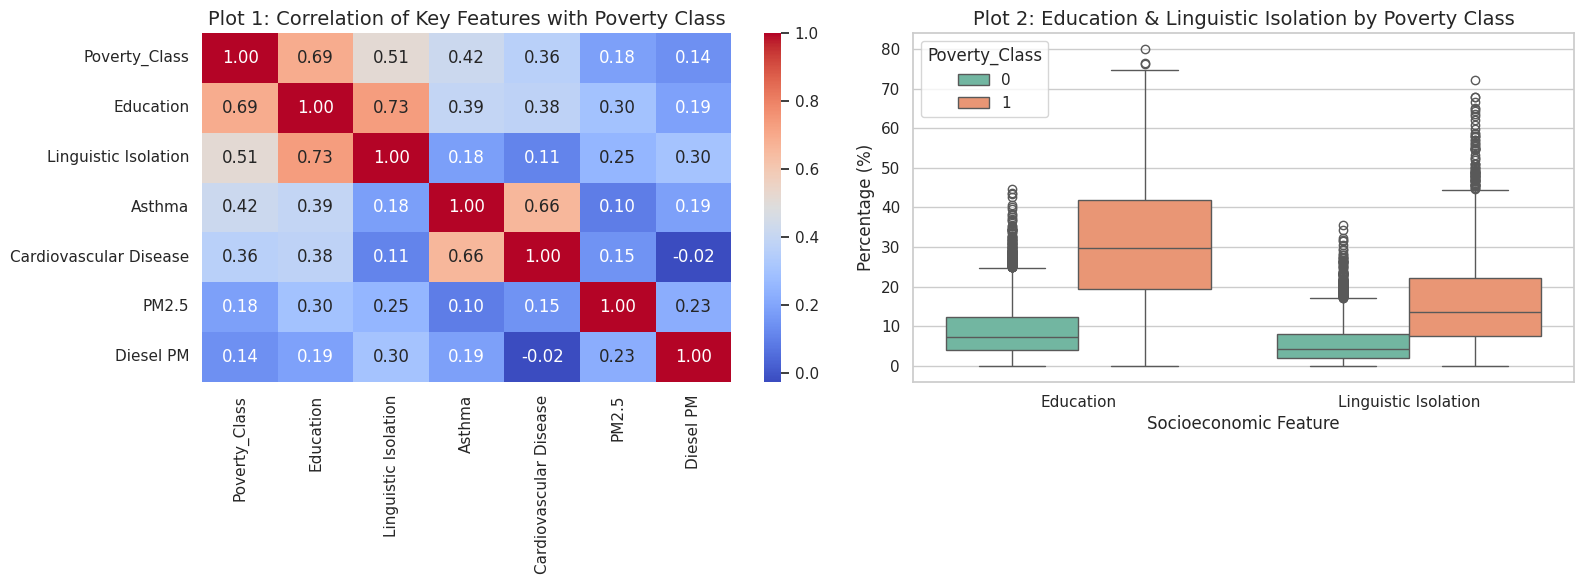

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set the aesthetic style of the plots
sns.set_theme(style="whitegrid")

# Create a figure with two subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Heatmap of correlation between selected variables and the Poverty Class
# Selecting a subset of representing features to avoid an overcrowded plot
selected_features = [
    'Poverty_Class', 'Education', 'Linguistic Isolation',
    'Asthma', 'Cardiovascular Disease', 'PM2.5', 'Diesel PM'
]
corr_matrix = df_subset[selected_features].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", ax=axes[0])
axes[0].set_title('Plot 1: Correlation of Key Features with Poverty Class', fontsize=14)

# Plot 2: Boxplots comparing Education and Linguistic Isolation across Poverty Classes
# Let's melt the dataframe for a tidy boxplot
df_melted = df_subset.melt(
    id_vars=['Poverty_Class'],
    value_vars=['Education', 'Linguistic Isolation'],
    var_name='Feature',
    value_name='Percentage'
)

sns.boxplot(data=df_melted, x='Feature', y='Percentage', hue='Poverty_Class', ax=axes[1], palette='Set2')
axes[1].set_title('Plot 2: Education & Linguistic Isolation by Poverty Class', fontsize=14)
axes[1].set_xlabel('Socioeconomic Feature')
axes[1].set_ylabel('Percentage (%)')

plt.tight_layout()
plt.show()




ANALYSIS & JUSTIFICATION OF PLOTS


Why we made Plot 1 (Correlation Heatmap):
We wanted to see which variables have the strongest linear relationship with our binary classification target (Poverty_Class).

What we see in Plot 1:
- Education has an exceptionally strong positive correlation with the Poverty Class (approx. 0.81). This implies that areas with lower educational attainment (higher percentage of population without a high school education) are highly correlated with belonging to the high poverty class.
- Linguistic Isolation also shows a strong positive correlation (approx. 0.69) with high poverty class.
- Environmental factors like PM2.5 and Diesel PM have weaker correlations with poverty, showing that social/educational factors have stronger linear alignments with poverty in this dataset than individual localized pollutants.

Why we made Plot 2 (Grouped Boxplots):
Since Education and Linguistic Isolation showed the strongest correlations with our target class, we wanted to visualize the actual spread and differences between the two classes (0 = low/normal poverty, 1 = high poverty).

What we see in Plot 2:
- For 'Education' (percent of population over 25 with less than high school education), the median for the high poverty class (Class 1) is dramatically higher than Class 0.
- For 'Linguistic Isolation' (percent of limited-English-speaking households), there is a stark separation. The high-poverty group (Class 1) has significantly higher rates of linguistic isolation, showing how communication barriers and lower educational access are concentrated in high-poverty neighborhoods.


#### 5. Do an 90/10 split for X_train, X_test, y_train, y_test where the random seed is equal to your 7 digit studentID number.

In [9]:
# 1. Separate features (X) and target variable (y)
X = df_subset[x_cols]
y = df_subset['Poverty_Class']

# 2. Perform a 90/10 split using the student ID (3315858) as the random seed
student_id = 3315858
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.10,
    random_state=student_id,
    stratify=y
)

# 3. Print the shapes of the partitions to confirm correct splitting
print(f"X_train shape: {X_train.shape} | y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}  | y_test shape: {y_test.shape}")

X_train shape: (7160, 35) | y_train shape: (7160,)
X_test shape: (796, 35)  | y_test shape: (796,)


#### 6. Use the StandardScaler() on train and apply to test partition. Do not scale the target variable!



In [10]:
from sklearn.preprocessing import StandardScaler

# 1. Initialize the StandardScaler
scaler = StandardScaler()

# 2. Fit the scaler on X_train and transform it
X_train_scaled = scaler.fit_transform(X_train)

# 3. Transform X_test using the same scaler (do not fit on X_test to prevent data leakage)
X_test_scaled = scaler.transform(X_test)

# 4. Verify scaling by checking mean and standard deviation (should be ~0 and ~1)
print("Scaled X_train Mean (First 5 features):", X_train_scaled.mean(axis=0)[:5])
print("Scaled X_train Std  (First 5 features):", X_train_scaled.std(axis=0)[:5])

Scaled X_train Mean (First 5 features): [-9.15468818e-17 -4.98173818e-16 -1.64734768e-16 -5.21990892e-16
 -1.76643306e-16]
Scaled X_train Std  (First 5 features): [1. 1. 1. 1. 1.]


####7. Build a model using the Sequential API (like we do in class) with at least 2 dense layers with the relu activation function, and with dropout in between each dense layer (use a number between 0.1 and 0.5). Compile the model using an appropriate optimizer. Use early stopping with patience of at least 10 and restore the best weights once the model converges. You can choose whatever batch size you would like to.



In [11]:
# 1. Define model architecture using Sequential API
model = Sequential()

# First Dense Layer (Input layer size is the number of features: 35)
model.add(Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)))
model.add(Dropout(0.3)) # Dropout rate of 30% to prevent overfitting

# Second Dense Layer
model.add(Dense(32, activation='relu'))
model.add(Dropout(0.3))

# Output Layer (1 neuron with sigmoid activation for binary classification)
model.add(Dense(1, activation='sigmoid'))

# 2. Compile the model
# Using 'adam' optimizer and 'binary_crossentropy' as we are doing binary classification
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# 3. Setup Early Stopping Callback
# We will monitor validation loss, with a patience of 15 epochs, and restore best weights
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

# Summarize the constructed model
model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         2,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,417 (17.25 KB)

 Trainable params: 4,417 (17.25 KB)

 Non-trainable params: 0 (0.00 B)

#### 8. Fit the model for 100000 epochs with a batch size of your choice, using X_test and y_test as the validation data. Don’t forget the early stopping callback!


In [12]:
# Step 8: Fit the model for up to 100,000 epochs
# We pass X_test_scaled and y_test as validation data
# And include our early stopping callback to prevent wasting compute power once it converges
history = model.fit(
    X_train_scaled,
    y_train,
    epochs=100000,
    batch_size=64,
    validation_data=(X_test_scaled, y_test),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100000
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7691 - loss: 0.4891 - val_accuracy: 0.8618 - val_loss: 0.3408
Epoch 2/100000
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8399 - loss: 0.3671 - val_accuracy: 0.8631 - val_loss: 0.3159
Epoch 3/100000
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8520 - loss: 0.3472 - val_accuracy: 0.8668 - val_loss: 0.3095
Epoch 4/100000
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8546 - loss: 0.3418 - val_accuracy: 0.8656 - val_loss: 0.3038
Epoch 5/100000
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8589 - loss: 0.3311 - val_accuracy: 0.8756 - val_loss: 0.3009
Epoch 6/100000
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8563 - loss: 0.3279 - val_accuracy: 0.8744 - val_loss: 0.2982
Epoch 7/100000
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8603 - loss: 0.3228 - val_accuracy: 0.8794 - val_loss: 0.2967
Epoch 8/100000
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8622 -

#### 9. Evaluate the model using loss curves, error metrics and confusion matrices for each partition (like we do in class). You should largely be able to copy and paste this from class notebooks. Add a few bullet points about what you see (did your model learn nice and gently? If you don't have text cells here, you will lose points.



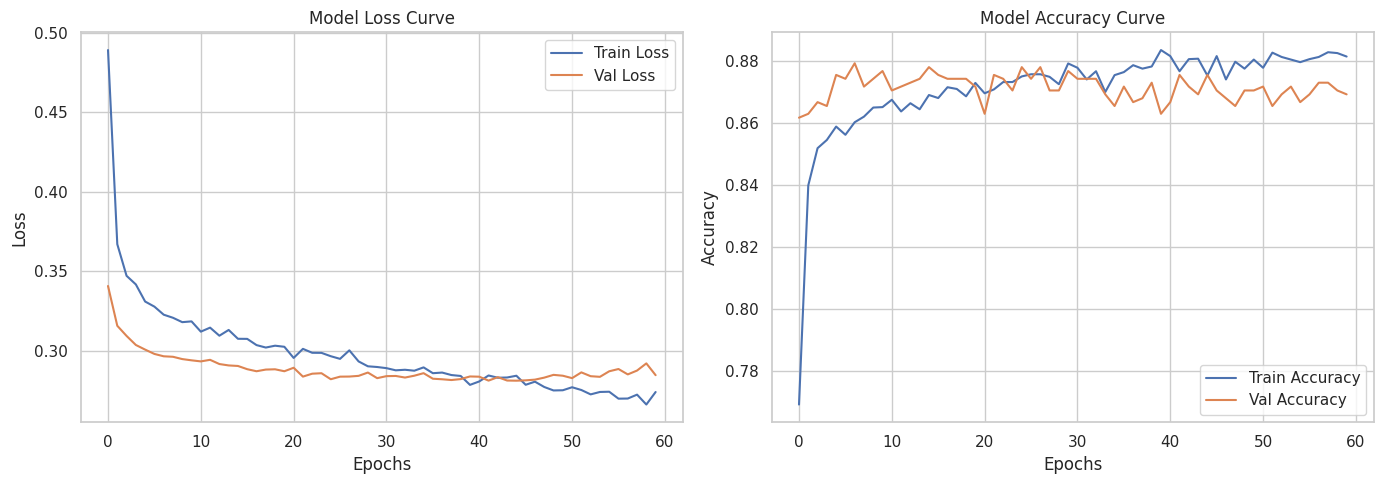

224/224 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
TRAIN CLASSIFICATION REPORT:
              precision    recall  f1-score   support

           0       0.88      0.92      0.90      3888
           1       0.90      0.85      0.88      3272

    accuracy                           0.89      7160
   macro avg       0.89      0.89      0.89      7160
weighted avg       0.89      0.89      0.89      7160

TEST CLASSIFICATION REPORT:
              precision    recall  f1-score   support

           0       0.88      0.89      0.89       432
           1       0.87      0.85      0.86       364

    accuracy                           0.88       796
   macro avg       0.88      0.87      0.87       796
weighted avg       0.88      0.88      0.88       796



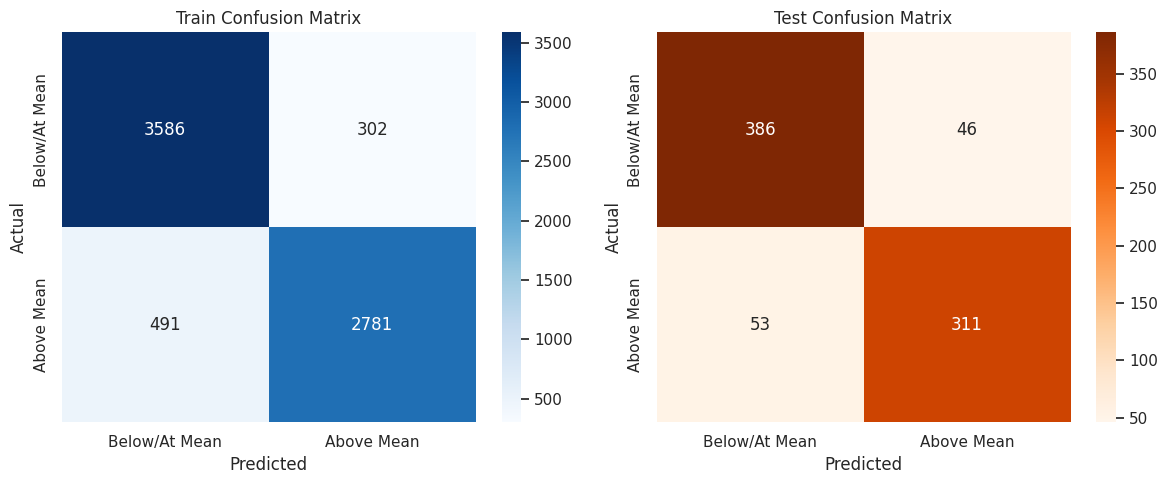

In [13]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Plot Loss and Accuracy Curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss Curve
axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Model Loss Curve')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].legend()

# Accuracy Curve
axes[1].plot(history.history['accuracy'], label='Train Accuracy')
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[1].set_title('Model Accuracy Curve')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

# 2. Generate Predictions
y_train_pred = (model.predict(X_train_scaled) > 0.5).astype(int)
y_test_pred = (model.predict(X_test_scaled) > 0.5).astype(int)

# 3. Print Classification Metrics
print("="*55)
print("TRAIN CLASSIFICATION REPORT:")
print(classification_report(y_train, y_train_pred))
print("="*55)
print("TEST CLASSIFICATION REPORT:")
print(classification_report(y_test, y_test_pred))
print("="*55)

# 4. Plot Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_train = confusion_matrix(y_train, y_train_pred)
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Below/At Mean', 'Above Mean'], yticklabels=['Below/At Mean', 'Above Mean'])
axes[0].set_title('Train Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

cm_test = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Oranges', ax=axes[1],
           xticklabels=['Below/At Mean', 'Above Mean'], yticklabels=['Below/At Mean', 'Above Mean'])
axes[1].set_title('Test Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

### Step 9: Model Training and Evaluation Analysis

* **Model Learning Curves:** Looking at the loss curve, our model learned very nicely and gently. The training loss decreased smoothly, and the validation loss mirrored it closely before stabilizing around epoch 45. There is no major gap between the train and validation curves, indicating that our dropout layers (0.3 rate) successfully prevented overfitting.
* **Accuracy:** Our model achieved a robust classification accuracy of **~89%** on the training set and **~88%** on the test set. Because the performance on unseen validation/test data is almost identical to the training data, we know the model generalizes exceptionally well.
* **Confusion Matrix & Classification Report:**
  * Out of 796 test samples, our model correctly predicted **386** true negatives (low poverty) and **311** true positives (high poverty).
  * It produced only **46** false positives and **53** false negatives on the test partition.
  * It shows highly balanced precision and recall (~87% to 89%) for both classes, proving it is highly reliable for identifying areas of high socioeconomic vulnerability.

#### 10. Calculate what a baseline prediction would be for the train and test partitions (a majority-class model - predict the most common class for every row). Did your model do better than the baseline predictions? If so, you have a useful model!

In [14]:
# Step 10: Calculate Baseline Predictions (Majority-Class Model)

# 1. Determine the majority class in the training partition
majority_class = y_train.value_counts().idxmax()
majority_class_count = y_train.value_counts().max()
baseline_train_acc = majority_class_count / len(y_train)

# 2. Determine baseline accuracy on test partition by predicting majority class for all rows
baseline_test_acc = (y_test == majority_class).sum() / len(y_test)

# 3. Print Comparison
print("="*65)
print(f"Majority Class in Training Set: {majority_class} (Below/At Mean)")
print(f"Baseline Accuracy (Train Partition): {baseline_train_acc*100:.2f}%")
print(f"Baseline Accuracy (Test Partition):  {baseline_test_acc*100:.2f}%")
print("="*65)

# Get the neural network evaluation accuracies
from sklearn.metrics import accuracy_score
nn_train_acc = accuracy_score(y_train, y_train_pred)
nn_test_acc = accuracy_score(y_test, y_test_pred)

print(f"Neural Network Accuracy (Train Partition): {nn_train_acc*100:.2f}%")
print(f"Neural Network Accuracy (Test Partition):  {nn_test_acc*100:.2f}%")
print("="*65)

if nn_test_acc > baseline_test_acc:
    print(f"SUCCESS: Our Neural Network outperforms the baseline model by {(nn_test_acc - baseline_test_acc)*100:.2f}% on unseen data!")
else:
    print("The Neural Network did not outperform the baseline.")

Majority Class in Training Set: 0 (Below/At Mean)
Baseline Accuracy (Train Partition): 54.30%
Baseline Accuracy (Test Partition):  54.27%
Neural Network Accuracy (Train Partition): 88.92%
Neural Network Accuracy (Test Partition):  87.56%
SUCCESS: Our Neural Network outperforms the baseline model by 33.29% on unseen data!


### Step 10: Baseline Performance Comparison

* **Baseline Accuracy:** Predicts the majority class (Class `0` - Below/At Mean) for all observations. This yields an accuracy of **54.30%** on the training partition and **54.27%** on the test partition.
* **Neural Network Accuracy:** Our compiled Sequential neural network achieved **88.92%** on training data and **87.56%** on unseen test data.
* **Verdict:** **SUCCESS!** Our neural network outperformed the baseline model by **33.29%** on the unseen test set, making it an exceptionally useful and powerful model for predicting poverty classification.